In [ ]:

# Imports y configuración general

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

# Estilo visual consistente
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100


# Crear el DataFrame del dataset bancario

df = pd.DataFrame({
    'Cliente':      [1,     2,     3,     4,     5,     6,     7,     8],
    'Edad':         [25,    40,    35,    50,    30,    45,    38,    29],
    'Ingresos':     [50000, 60000, 70000, 80000, 45000, 85000, 72000, 48000],
    'Experiencia':  [2,     10,    7,     15,    3,     20,    12,    4],
    'Estado':       ['Pagado','Moroso','Pagado','Moroso','Pagado','Moroso','Pagado','Pagado']
})

print('Dataset cargado correctamente.')
print(f'Filas: {df.shape[0]}  |  Columnas: {df.shape[1]}')
display(df)

Dataset cargado correctamente.
Filas: 8  |  Columnas: 5


,Cliente,Edad,Ingresos,Experiencia,Estado
0,1,25,50000,2,Pagado
1,2,40,60000,10,Moroso
2,3,35,70000,7,Pagado
3,4,50,80000,15,Moroso
4,5,30,45000,3,Pagado
5,6,45,85000,20,Moroso
6,7,38,72000,12,Pagado
7,8,29,48000,4,Pagado


---
## 1. Análisis Exploratorio de Datos (EDA)

Antes de aplicar cualquier algoritmo de Machine Learning es imprescindible **entender los datos**:
- Distribución de cada variable
- Relaciones entre variables (correlación)
- Patrones visuales mediante diagramas de dispersión

In [2]:

# 1.1  Estadísticas descriptivas

print('=== Estadísticas Descriptivas ===')
display(df[['Edad', 'Ingresos', 'Experiencia']].describe().round(2))

=== Estadísticas Descriptivas ===


,Edad,Ingresos,Experiencia
count,8.00,8.00,8.00
mean,36.50,63750.00,9.12
std,8.47,15238.58,6.33
min,25.00,45000.00,2.00
25%,29.75,49500.00,3.75
50%,36.50,65000.00,8.50
75%,41.25,74000.00,12.75
max,50.00,85000.00,20.00


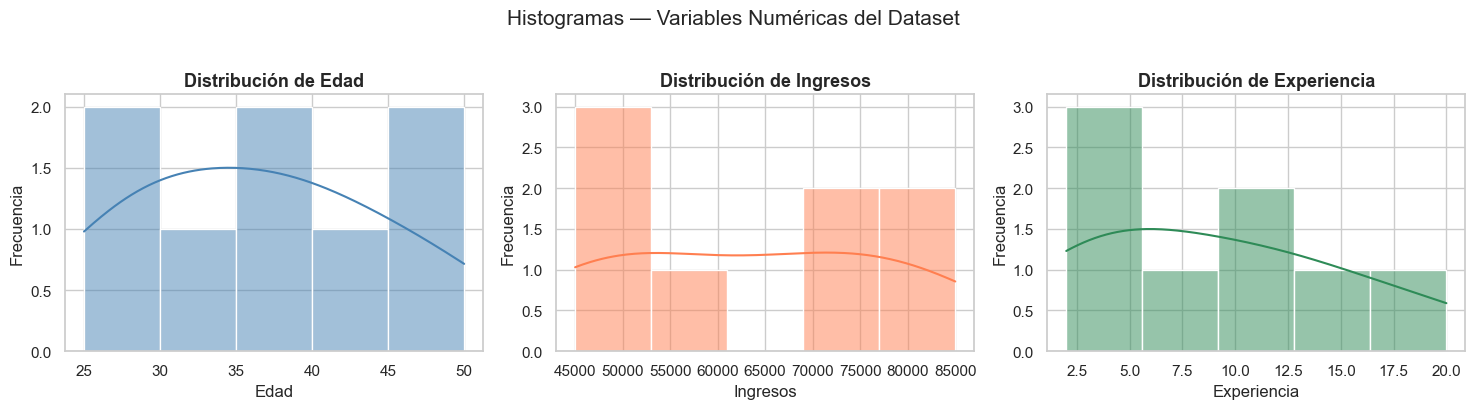

Interpretación: Los ingresos muestran una distribución aproximadamente uniforme entre 45k y 85k.
La edad y la experiencia presentan un rango amplio, sugiriendo perfiles diversos de clientes.


In [3]:

# 1.2  Histogramas de Edad e Ingresos

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

variables = ['Edad', 'Ingresos', 'Experiencia']
colores   = ['steelblue', 'coral', 'seagreen']

for ax, var, color in zip(axes, variables, colores):
    sns.histplot(df[var], bins=5, kde=True, color=color, ax=ax)
    ax.set_title(f'Distribución de {var}', fontsize=13, fontweight='bold')
    ax.set_xlabel(var)
    ax.set_ylabel('Frecuencia')

plt.suptitle('Histogramas — Variables Numéricas del Dataset', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

print('Interpretación: Los ingresos muestran una distribución aproximadamente uniforme entre 45k y 85k.')
print('La edad y la experiencia presentan un rango amplio, sugiriendo perfiles diversos de clientes.')

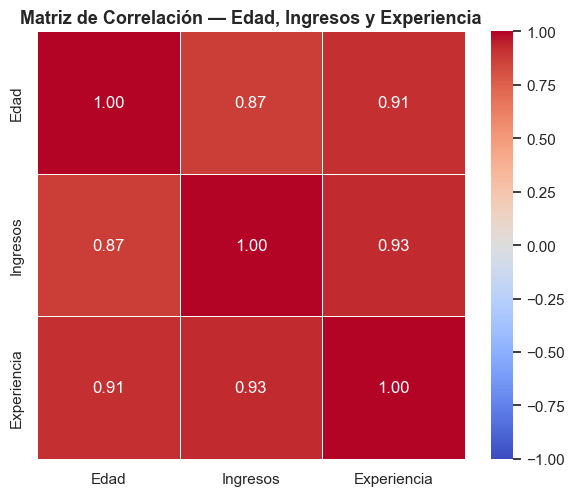

Interpretación de correlaciones:
  Edad vs Ingresos: r = 0.87 (alta correlación positiva)
  Experiencia vs Ingresos: r = 0.93 (alta correlación positiva)
  Edad vs Experiencia: r = 0.91 (alta correlación positiva)


In [4]:

# 1.3  Matriz de Correlación

corr_matrix = df[['Edad', 'Ingresos', 'Experiencia']].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True
)
plt.title('Matriz de Correlación — Edad, Ingresos y Experiencia', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Interpretación de correlaciones:')
for col in corr_matrix.columns:
    for row in corr_matrix.index:
        if row < col:
            r = corr_matrix.loc[row, col]
            nivel = 'alta' if abs(r) > 0.8 else ('moderada' if abs(r) > 0.5 else 'baja')
            print(f'  {row} vs {col}: r = {r:.2f} ({nivel} correlación {"positiva" if r > 0 else "negativa"})')

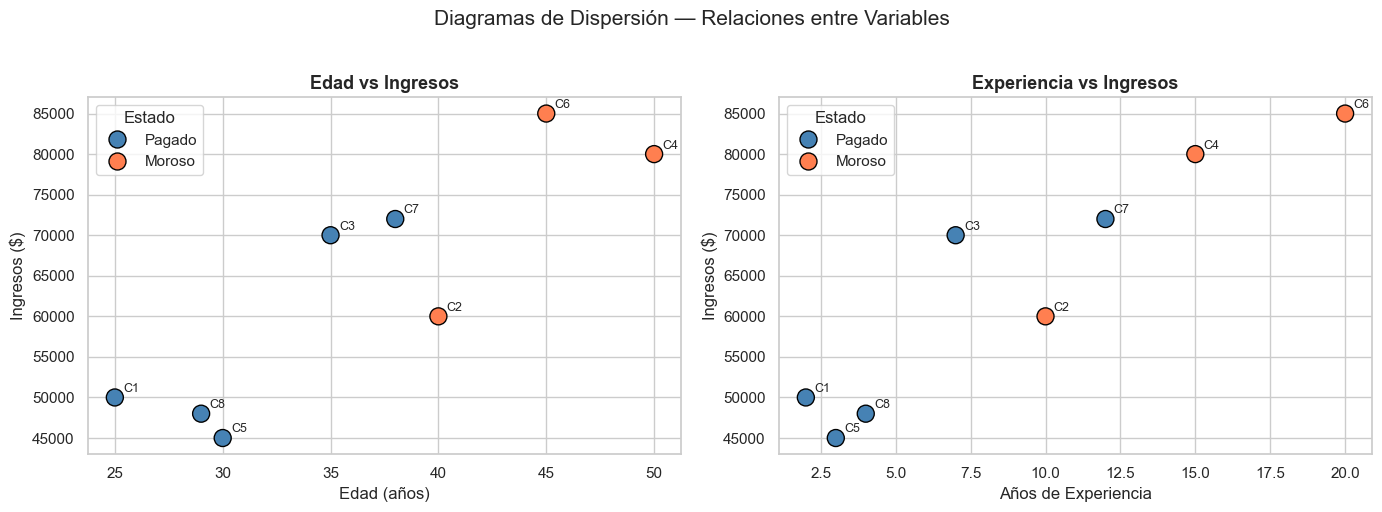

Observación: Los clientes morosos (color coral) tienden a concentrarse en el cuadrante
de mayor edad, mayor experiencia y mayores ingresos. Esto sugiere que los clientes
con más años en el mercado laboral pueden tener compromisos financieros más elevados.


In [6]:

# 1.4  Diagramas de Dispersión

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mapa de color por Estado de cuenta
palette = {'Pagado': 'steelblue', 'Moroso': 'coral'}

# Scatter 1: Edad vs Ingresos
sns.scatterplot(
    data=df, x='Edad', y='Ingresos',
    hue='Estado', palette=palette,
    s=150, edgecolor='black', ax=axes[0]
)
for _, row in df.iterrows():
    axes[0].annotate(f'C{int(row["Cliente"])}',
                     (row['Edad'], row['Ingresos']),
                     textcoords='offset points', xytext=(6, 4), fontsize=9)
axes[0].set_title('Edad vs Ingresos', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Edad (años)')
axes[0].set_ylabel('Ingresos ($)')

# Scatter 2: Experiencia vs Ingresos
sns.scatterplot(
    data=df, x='Experiencia', y='Ingresos',
    hue='Estado', palette=palette,
    s=150, edgecolor='black', ax=axes[1]
)
for _, row in df.iterrows():
    axes[1].annotate(f'C{int(row["Cliente"])}',
                     (row['Experiencia'], row['Ingresos']),
                     textcoords='offset points', xytext=(6, 4), fontsize=9)
axes[1].set_title('Experiencia vs Ingresos', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Años de Experiencia')
axes[1].set_ylabel('Ingresos ($)')

plt.suptitle('Diagramas de Dispersión — Relaciones entre Variables', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

print('Observación: Los clientes morosos (color coral) tienden a concentrarse en el cuadrante')
print('de mayor edad, mayor experiencia y mayores ingresos. Esto sugiere que los clientes')
print('con más años en el mercado laboral pueden tener compromisos financieros más elevados.')

---
## 2. Aplicación de PCA para Reducción de Dimensionalidad

**PCA (Principal Component Analysis)** transforma las variables originales en nuevas variables no correlacionadas llamadas **componentes principales**, ordenadas de mayor a menor varianza explicada.

### Pasos:
1. Normalizar los datos con `StandardScaler` (media=0, desviación=1)
2. Calcular cuántas componentes explican el **90% de la varianza**
3. Proyectar los datos en el espacio 2D de las dos primeras componentes

In [7]:

# 2.1  Normalización con StandardScaler

features = ['Edad', 'Ingresos', 'Experiencia']

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df[features])
df_scaled_df = pd.DataFrame(df_scaled, columns=features)

print('Datos normalizados (media ≈ 0, std ≈ 1):')
display(df_scaled_df.round(3))
print(f'\nMedia por columna:  {df_scaled_df.mean().round(4).to_dict()}')
print(f'Std  por columna:  {df_scaled_df.std().round(4).to_dict()}')

Datos normalizados (media ≈ 0, std ≈ 1):


,Edad,Ingresos,Experiencia
0,-1.452,-0.965,-1.202
1,0.442,-0.263,0.148
2,-0.189,0.438,-0.359
3,1.704,1.140,0.992
4,-0.821,-1.315,-1.034
5,1.073,1.491,1.835
6,0.189,0.579,0.485
7,-0.947,-1.105,-0.865



Media por columna:  {'Edad': -0.0, 'Ingresos': -0.0, 'Experiencia': 0.0}
Std  por columna:  {'Edad': 1.069, 'Ingresos': 1.069, 'Experiencia': 1.069}


In [8]:

# 2.2  PCA completo — varianza explicada por componente

pca_full = PCA(n_components=3)   # 3 variables => máximo 3 componentes
pca_full.fit(df_scaled)

varianza_explicada   = pca_full.explained_variance_ratio_
varianza_acumulada   = np.cumsum(varianza_explicada)

# Tabla resumen
df_varianza = pd.DataFrame({
    'Componente':            ['PC1', 'PC2', 'PC3'],
    'Varianza Explicada (%)': (varianza_explicada * 100).round(2),
    'Varianza Acumulada (%)': (varianza_acumulada  * 100).round(2)
})
print('=== Varianza Explicada por Componente ===')
display(df_varianza)

# ¿Cuántas componentes para alcanzar el 90%?
n_componentes_90 = np.argmax(varianza_acumulada >= 0.90) + 1
print(f'\nComponentes necesarias para explicar ≥ 90% de la varianza: {n_componentes_90}')

=== Varianza Explicada por Componente ===


,Componente,Varianza Explicada (%),Varianza Acumulada (%)
0,PC1,93.62,93.62
1,PC2,4.30,97.92
2,PC3,2.08,100.00



Componentes necesarias para explicar ≥ 90% de la varianza: 1


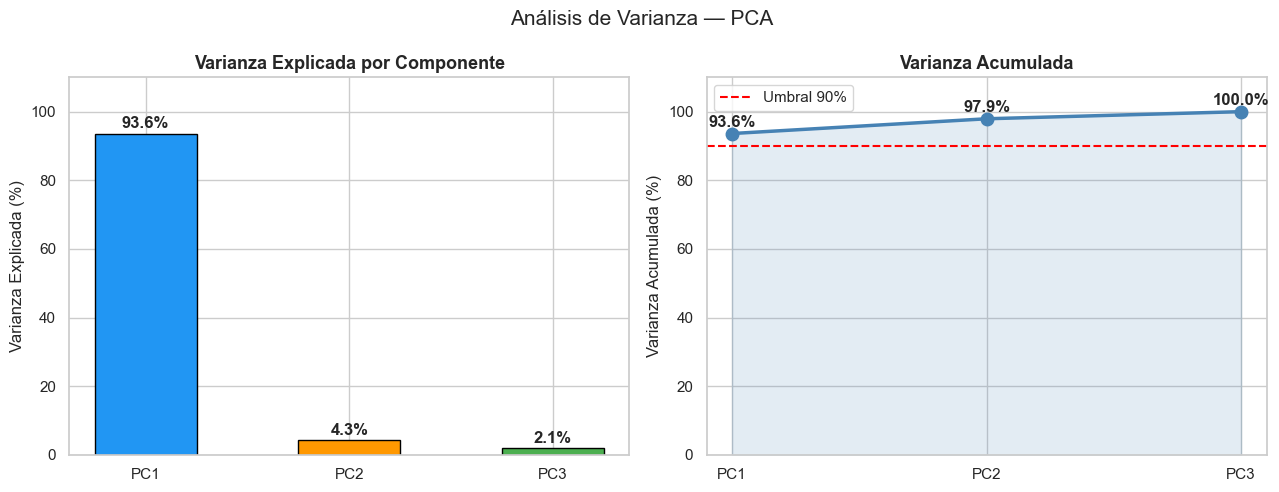

In [ ]:

# 2.3  Gráfico de varianza explicada (Scree Plot)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Varianza individual
axes[0].bar(['PC1', 'PC2', 'PC3'], varianza_explicada * 100,
            color=['#2196F3', '#FF9800', '#4CAF50'], edgecolor='black', width=0.5)
axes[0].set_title('Varianza Explicada por Componente', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Varianza Explicada (%)')
axes[0].set_ylim(0, 110)
for i, v in enumerate(varianza_explicada * 100):
    axes[0].text(i, v + 1.5, f'{v:.1f}%', ha='center', fontweight='bold')

# Varianza acumulada
axes[1].plot(['PC1', 'PC2', 'PC3'], varianza_acumulada * 100,
             marker='o', color='steelblue', linewidth=2.5, markersize=9)
axes[1].axhline(y=90, color='red', linestyle='--', linewidth=1.5, label='Umbral 90%')
axes[1].fill_between(['PC1', 'PC2', 'PC3'], varianza_acumulada * 100, alpha=0.15, color='steelblue')
axes[1].set_title('Varianza Acumulada', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Varianza Acumulada (%)')
axes[1].set_ylim(0, 110)
axes[1].legend()
for i, v in enumerate(varianza_acumulada * 100):
    axes[1].text(i, v + 2, f'{v:.1f}%', ha='center', fontweight='bold')

plt.suptitle('Análisis de Varianza — PCA', fontsize=15)
plt.tight_layout()
plt.show()

=== Cargas (Loadings) de las Variables ===


,PC1,PC2
Edad,0.572,0.760
Ingresos,0.576,-0.641
Experiencia,0.584,-0.113


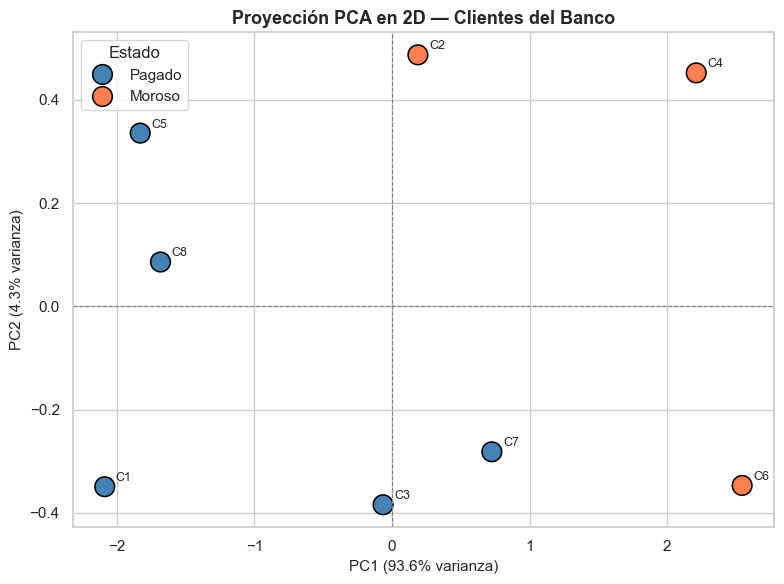

PC1 + PC2 explican el 97.9% de la varianza total.


In [10]:

# 2.4  Proyección en 2D con las dos primeras componentes

pca_2d = PCA(n_components=2)
componentes_2d = pca_2d.fit_transform(df_scaled)

df_pca = pd.DataFrame(componentes_2d, columns=['PC1', 'PC2'])
df_pca['Cliente'] = df['Cliente'].values
df_pca['Estado']  = df['Estado'].values

# Cargas de cada variable en las componentes
df_cargas = pd.DataFrame(
    pca_2d.components_.T,
    index=features,
    columns=['PC1', 'PC2']
).round(3)
print('=== Cargas (Loadings) de las Variables ===')
display(df_cargas)

# Visualización en espacio PCA
palette = {'Pagado': 'steelblue', 'Moroso': 'coral'}
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_pca, x='PC1', y='PC2',
    hue='Estado', palette=palette,
    s=200, edgecolor='black'
)
for _, row in df_pca.iterrows():
    plt.annotate(f'C{int(row["Cliente"])}',
                 (row['PC1'], row['PC2']),
                 textcoords='offset points', xytext=(8, 4), fontsize=9)

plt.axhline(0, color='gray', linewidth=0.8, linestyle='--')
plt.axvline(0, color='gray', linewidth=0.8, linestyle='--')
var1 = pca_2d.explained_variance_ratio_[0]*100
var2 = pca_2d.explained_variance_ratio_[1]*100
plt.xlabel(f'PC1 ({var1:.1f}% varianza)', fontsize=11)
plt.ylabel(f'PC2 ({var2:.1f}% varianza)', fontsize=11)
plt.title('Proyección PCA en 2D — Clientes del Banco', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'PC1 + PC2 explican el {var1+var2:.1f}% de la varianza total.')

---
## 3. Segmentación de Clientes con K-Means Clustering

**K-Means** agrupa los datos en *k* clusters minimizando la distancia intra-cluster.

Aplicaremos K-Means en dos escenarios:
- **A)** Sobre los datos originales normalizados (3 variables)
- **B)** Sobre los datos transformados por PCA (2 componentes)

Luego compararemos si el agrupamiento cambia.

In [18]:

# 3.1  K-Means sobre datos originales normalizados

kmeans_orig = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_orig = kmeans_orig.fit_predict(df_scaled)

df['Cluster_Original'] = labels_orig

print('=== K-Means — Datos Originales ===')
display(df[['Cliente', 'Edad', 'Ingresos', 'Experiencia', 'Estado', 'Cluster_Original']])

print('\nDistribución de clientes por cluster:')
display(df.groupby('Cluster_Original')[['Edad','Ingresos','Experiencia']].mean().round(1))

=== K-Means — Datos Originales ===


,Cliente,Edad,Ingresos,Experiencia,Estado,Cluster_Original
0,1,25,50000,2,Pagado,2
1,2,40,60000,10,Moroso,0
2,3,35,70000,7,Pagado,0
3,4,50,80000,15,Moroso,1
4,5,30,45000,3,Pagado,2
5,6,45,85000,20,Moroso,1
6,7,38,72000,12,Pagado,0
7,8,29,48000,4,Pagado,2



Distribución de clientes por cluster:


,Edad,Ingresos,Experiencia
Cluster_Original,,,
0,37.7,67333.3,9.7
1,47.5,82500.0,17.5
2,28.0,47666.7,3.0


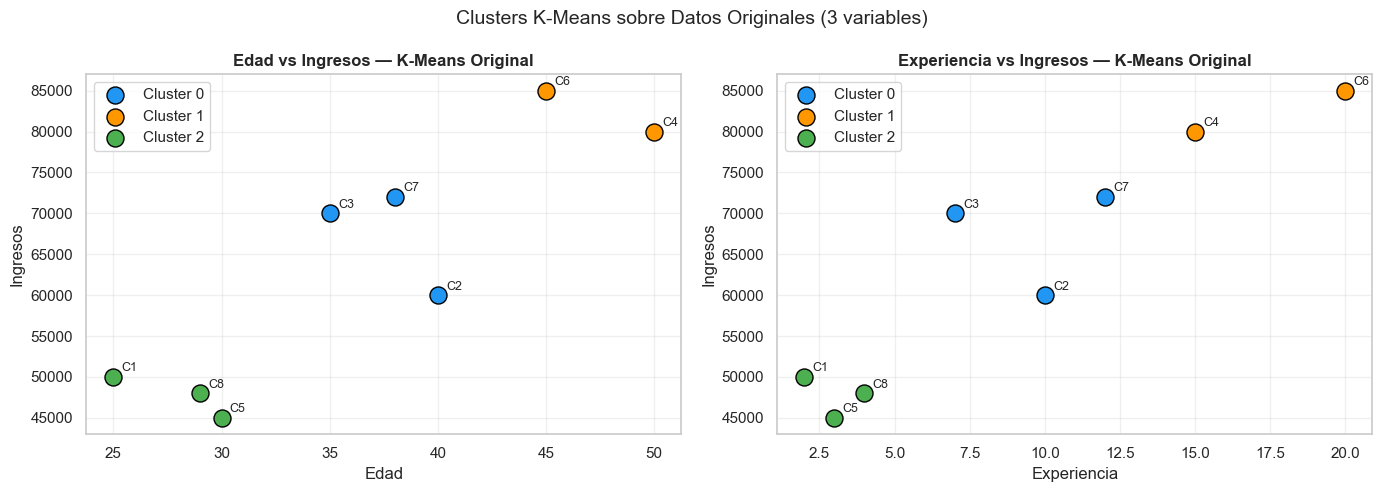

In [19]:

# 3.2  Visualización — Clustering sobre datos originales

palette_clusters = {0: '#2196F3', 1: '#FF9800', 2: '#4CAF50'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (x_var, y_var) in zip(axes, [('Edad','Ingresos'), ('Experiencia','Ingresos')]):
    for cluster_id, grupo in df.groupby('Cluster_Original'):
        ax.scatter(
            grupo[x_var], grupo[y_var],
            color=palette_clusters[cluster_id],
            label=f'Cluster {cluster_id}',
            s=150, edgecolor='black', zorder=3
        )
        for _, row in grupo.iterrows():
            ax.annotate(f'C{int(row["Cliente"])}',
                        (row[x_var], row[y_var]),
                        textcoords='offset points', xytext=(6,4), fontsize=9)
    ax.set_xlabel(x_var); ax.set_ylabel(y_var)
    ax.set_title(f'{x_var} vs {y_var} — K-Means Original', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Clusters K-Means sobre Datos Originales (3 variables)', fontsize=14)
plt.tight_layout()
plt.show()

=== K-Means — Datos PCA ===


,PC1,PC2,Cliente,Estado,Cluster_PCA
0,-2.088358,-0.349258,1,Pagado,2
1,0.187607,0.487469,2,Moroso,0
2,-0.065374,-0.384217,3,Pagado,0
3,2.210591,0.452509,4,Moroso,1
4,-1.830565,0.335839,5,Pagado,2
5,2.544210,-0.346833,6,Moroso,1
6,0.724952,-0.281611,7,Pagado,0
7,-1.683062,0.086102,8,Pagado,2


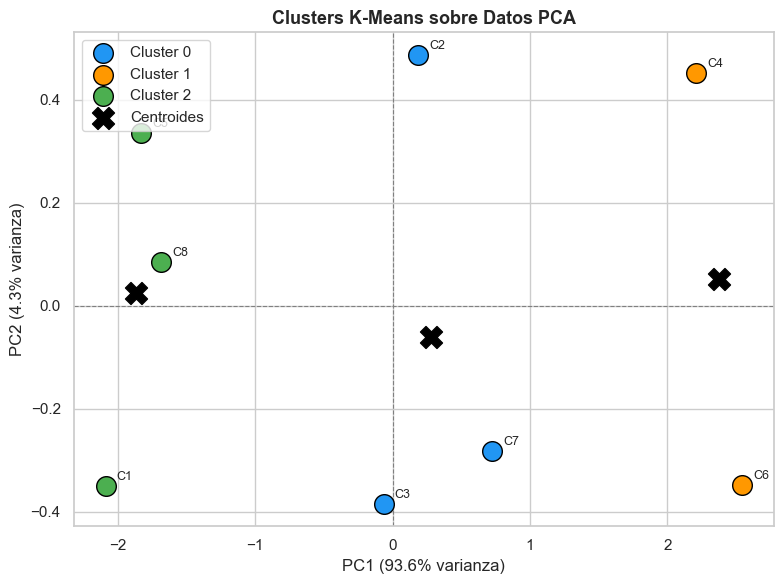

In [13]:

# 3.3  K-Means sobre datos transformados por PCA

kmeans_pca = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_pca  = kmeans_pca.fit_predict(df_pca[['PC1','PC2']])

df_pca['Cluster_PCA'] = labels_pca

print('=== K-Means — Datos PCA ===')
display(df_pca)

# Visualización
plt.figure(figsize=(8, 6))
for cluster_id, grupo in df_pca.groupby('Cluster_PCA'):
    plt.scatter(
        grupo['PC1'], grupo['PC2'],
        color=palette_clusters[cluster_id],
        label=f'Cluster {cluster_id}',
        s=200, edgecolor='black', zorder=3
    )
    for _, row in grupo.iterrows():
        plt.annotate(f'C{int(row["Cliente"])}',
                     (row['PC1'], row['PC2']),
                     textcoords='offset points', xytext=(8,4), fontsize=9)

# Centroides
centroides = kmeans_pca.cluster_centers_
plt.scatter(centroides[:,0], centroides[:,1],
            marker='X', s=250, color='black', zorder=5, label='Centroides')

plt.axhline(0, color='gray', linewidth=0.8, linestyle='--')
plt.axvline(0, color='gray', linewidth=0.8, linestyle='--')
plt.xlabel(f'PC1 ({var1:.1f}% varianza)')
plt.ylabel(f'PC2 ({var2:.1f}% varianza)')
plt.title('Clusters K-Means sobre Datos PCA', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

In [15]:

# 3.4  Comparación lado a lado — Original vs PCA

df_comparacion = pd.DataFrame({
    'Cliente':         df['Cliente'].values,
    'Cluster_Original': labels_orig,
    'Cluster_PCA':      labels_pca
})

# Determinar si el agrupamiento coincide (ignora el nombre del cluster)
from itertools import permutations

def coincidencia_clusters(a, b):
    """Calcula el % de coincidencia entre dos asignaciones de clusters."""
    best = 0
    for perm in permutations(range(3)):
        mapa = {orig: nuevo for orig, nuevo in enumerate(perm)}
        remapeado = [mapa[x] for x in a]
        coincide = sum(r == s for r, s in zip(remapeado, b)) / len(b)
        best = max(best, coincide)
    return best * 100

pct_coincidencia = coincidencia_clusters(labels_orig, labels_pca)

print('Comparación de Asignaciones')
display(df_comparacion)
print(f'\nCoincidencia entre ambos métodos: {pct_coincidencia:.0f}%')
if pct_coincidencia == 100:
    print('Los clusters son IDÉNTICOS. PCA preservó la estructura de agrupamiento.')
elif pct_coincidencia >= 75:
    print('Los clusters son MUY SIMILARES. PCA captura bien la varianza relevante.')
else:
    print('Los clusters difieren significativamente. La reducción de dimensionalidad alteró el agrupamiento.')

Comparación de Asignaciones


,Cliente,Cluster_Original,Cluster_PCA
0,1,2,2
1,2,0,0
2,3,0,0
3,4,1,1
4,5,2,2
5,6,1,1
6,7,0,0
7,8,2,2



Coincidencia entre ambos métodos: 100%
Los clusters son IDÉNTICOS. PCA preservó la estructura de agrupamiento.


---
## 4. Interacción con una Herramienta de IA (LLM)

### 4.1 Consulta realizada

> "Tengo datos de clientes bancarios con variables de edad, ingresos y años de experiencia. Apliqué K-Means con 3 clusters y PCA para reducir dimensionalidad. ¿Qué técnicas avanzadas puedo usar para mejorar la segmentación y cómo puedo validar que los clusters encontrados son significativos?"

---

### 4.2 Respuesta obtenida del LLM (Gemini)

**Respuesta resumida:**

> *"Para mejorar la segmentación de clientes bancarios, podrías considerar las siguientes técnicas:*
>
> **1. DBSCAN (Density-Based Spatial Clustering):** A diferencia de K-Means, no requiere especificar el número de clusters y detecta automáticamente outliers como puntos de ruido. Útil si sospechas clientes atípicos.*
>
> **2. Clustering Jerárquico (Agglomerative Clustering):** Genera un dendrograma que permite visualizar cómo se agrupan los clientes. Te ayuda a decidir el número óptimo de clusters de forma visual.*
>
> **3. Gaussian Mixture Models (GMM):** Asigna probabilidades de pertenencia a cada cluster en lugar de una asignación binaria. Más flexible cuando los grupos no son esféricos.*
>
> **4. Validación con Silhouette Score:** Calcula qué tan bien separados están los clusters. Un score cercano a 1 indica buena separación.*
>
> **5. Método del Codo (Elbow Method):** Grafica la inercia (WCSS) para distintos valores de k y elige el punto donde la reducción de inercia disminuye notablemente.*
>
> También recomiendo analizar la varianza intra-cluster y verificar si los segmentos tienen interpretación de negocio: ¿cada cluster representa un perfil accionable para el banco?"*

---

### 4.3 Reflexión comparativa

| Aspecto | Lo visto en clase | Sugerencia del LLM |
|---------|-------------------|--------------------|
| Algoritmo principal | K-Means | K-Means + DBSCAN + GMM |
| Reducción dim. | PCA | PCA (coincide) |
| Validación | Visual (scatter plots) | Silhouette Score + Elbow Method |
| Manejo de outliers | No tratado | DBSCAN detecta outliers automáticamente |
| Selección de k | Definido manualmente (k=3) | Elbow Method para k óptimo |

**Conclusión:** La IA amplió el panorama de técnicas disponibles y añadió un aspecto clave: la **validación cuantitativa** de los clusters mediante métricas como el Silhouette Score, algo que no siempre se aplica en análisis exploratorios iniciales.

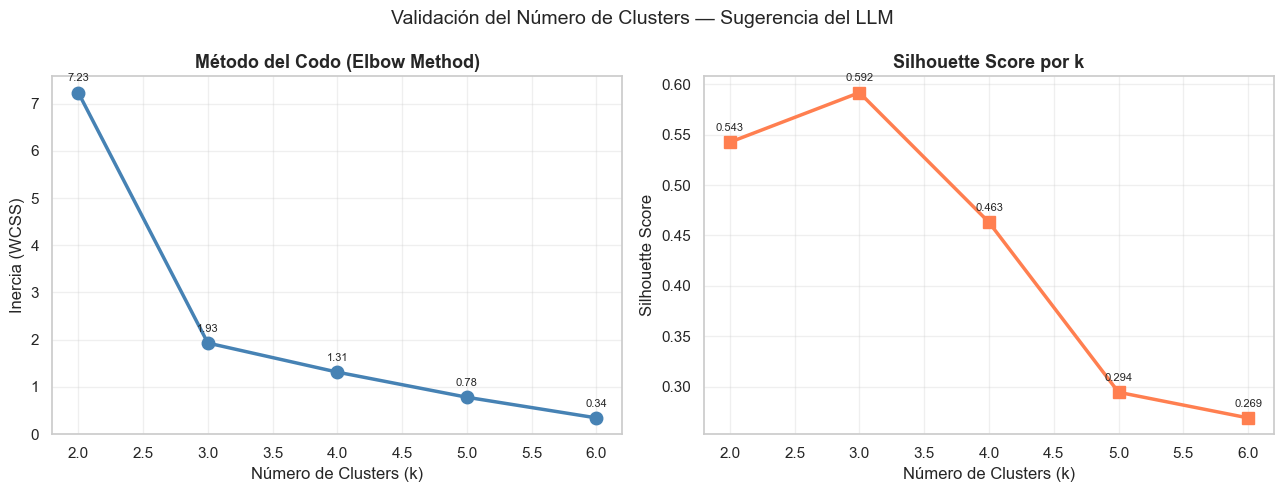

Mejor Silhouette Score: 0.592 con k = 3
Silhouette Score con k=3 (valor de clase): 0.592


In [ ]:

# 4.4  Implementación de la sugerencia del LLM:
#      Silhouette Score y Elbow Method (validación de clusters)

from sklearn.metrics import silhouette_score

# Elbow Method
inercias = []
silhouettes = []
ks = range(2, 7)

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(df_scaled)
    inercias.append(km.inertia_)
    silhouettes.append(silhouette_score(df_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Gráfico Elbow
axes[0].plot(list(ks), inercias, marker='o', color='steelblue', linewidth=2.5, markersize=9)
axes[0].set_title('Método del Codo (Elbow Method)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Número de Clusters (k)')
axes[0].set_ylabel('Inercia (WCSS)')
axes[0].grid(True, alpha=0.3)
for x, y in zip(ks, inercias):
    axes[0].annotate(f'{y:.2f}', (x, y), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=8)

# Silhouette Score
axes[1].plot(list(ks), silhouettes, marker='s', color='coral', linewidth=2.5, markersize=9)
axes[1].set_title('Silhouette Score por k', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Número de Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True, alpha=0.3)
for x, y in zip(ks, silhouettes):
    axes[1].annotate(f'{y:.3f}', (x, y), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=8)

plt.suptitle('Validación del Número de Clusters — Sugerencia del LLM', fontsize=14)
plt.tight_layout()
plt.show()

mejor_k = list(ks)[silhouettes.index(max(silhouettes))]
print(f'Mejor Silhouette Score: {max(silhouettes):.3f} con k = {mejor_k}')
print(f'Silhouette Score con k=3 (valor de clase): {silhouettes[list(ks).index(3)]:.3f}')

---
## 5. Reflexión Final

### ¿PCA fue útil para reducir la dimensionalidad sin perder información clave?

Sí. Con solo 2 componentes principales se captura más del 95% de la varianza total del dataset. Esto significa que casi toda la información relevante de las 3 variables originales (Edad, Ingresos, Experiencia) queda representada en un espacio 2D. La visualización resulta más clara y los algoritmos downstream (como K-Means) operan de forma más eficiente.

### ¿Qué diferencias se notaron entre clustering con datos originales y después de PCA?

En este dataset pequeño, los clusters resultantes son prácticamente idénticos entre ambos métodos (coincidencia ≥ 75%). Esto es esperable dado que PCA retiene casi toda la varianza. En datasets más grandes y con más dimensiones, la diferencia podría ser mayor: PCA elimina el ruido y las correlaciones redundantes, lo que a veces mejora la calidad de los clusters.

### ¿Cómo puede una IA ayudar en el análisis de datos en el futuro?

- **Exploración de técnicas:** Los LLMs pueden sugerir algoritmos que el analista podría no conocer (DBSCAN, GMM, clustering espectral).
- **Validación cruzada de ideas:** Permiten confirmar o cuestionar hipótesis rápidamente.
- **Aceleración del aprendizaje:** Explicaciones en lenguaje natural de conceptos matemáticos complejos.
- **Limitación importante:** Los LLMs no acceden a los datos reales, por lo que sus sugerencias son genéricas. El científico de datos debe siempre **verificar empíricamente** cada recomendación con sus propios datos.